In [1]:
from model import NeuralNetwork

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
from torch.nn import init

In [3]:
model = NeuralNetwork()

In [4]:
layers = [model.l1, model.l2, model.l3]

In [5]:
def init_control(layer, init_type: str):
    if hasattr(layer, 'weight') and layer.weight is not None:
        if init_type == "xavier":
            init.xavier_normal_(layer.weight)
        elif init_type == "kaiming":
            init.kaiming_normal_(layer.weight)
        elif init_type == "normal": 
            init.normal_(layer.weight, mean=0.0, std=0.02)
        else:
            raise ValueError(f"Unknown init_type: {init_type}")

        return layer.weight.detach().clone()


In [6]:
xavier_layers  = [init_control(layer, "xavier") for layer in layers]
kaiming_layers = [init_control(layer, "kaiming") for layer in layers]
normal_layers  = [init_control(layer, "normal") for layer in layers]

In [7]:
def convert_to_numpy(layer: torch.tensor):
    weights = layer.weight.detach().numpy()
    bias = layer.bias.detach().numpy()
    return weights, bias

In [8]:
numpy_weights =  []
numpy_bias = []
for layer in layers: 
    weights, bias = convert_to_numpy(layer)
    numpy_weights.append(weights)
    numpy_bias.append(bias)

In [9]:
def plot_singular_values(numpy_weights):
    i = 0
    for weight in numpy_weights:
        i += 1
        U, S, Vt = np.linalg.svd(weight)

        plt.figure()
        plt.plot(S)
        plt.title(f"Singular values – Layer {i}")
        plt.xlabel("Index")
        plt.ylabel("Magnitude")
        plt.show()
    

In [10]:
def plot_weight_distributions(weights, bins=50):
    i = 0
    for weight in weights:
        i+=1
        flat = weight.flatten()
        plt.figure()
        plt.hist(flat, bins=bins, density=True)
        plt.title(f"Weight distribution – Layer {i}")
        plt.xlabel("Weight value")
        plt.ylabel("Density")
        plt.show()

In [11]:
def plot_weight_heatmap(weights):
    i = 0
    for weight in weights: 
        i+=1
        plt.figure()
        plt.imshow(weight)
        plt.title(f"Weight distribution - Layer {i}")
        plt.ylabel("Heat Map")
        plt.show()

In [12]:
def square_matrix(layer):
    M = layer @ layer.T 
    return M

In [13]:
xavier_square_matrices = [square_matrix(layer) for layer in xavier_layers]
kaiming_square_matrices = [square_matrix(layer) for layer in kaiming_layers]
normal_square_matrices = [square_matrix(layer) for layer in normal_layers]

In [14]:
for i,layer in enumerate(xavier_square_matrices):
    print(f"Xavier Layer {i}: {np.linalg.det(layer)}")

for i,layer in enumerate(kaiming_square_matrices):
    print(f"Kaiming Layer {i}: {np.linalg.det(layer)}")

for i,layer in enumerate(normal_square_matrices):
    print(f"Normal Layer {i}: {np.linalg.det(layer)}")

Xavier Layer 0: 1.519051431643121e+22
Xavier Layer 1: 0.5305032730102539
Xavier Layer 2: 29.206607818603516
Kaiming Layer 0: 1.4960737408240956e+27
Kaiming Layer 1: 1578351104.0
Kaiming Layer 2: 428.7874450683594
Normal Layer 0: 0.0
Normal Layer 1: 0.0
Normal Layer 2: 9.240811817189196e-18


In [15]:
def convert_layer(layer):
    weights = layer.detach().numpy()
    return weights 

In [16]:
numpy_xavier_layers  = [convert_layer(layer) for layer in xavier_layers]
numpy_kaiming_layers = [convert_layer(layer) for layer in kaiming_layers]
numpy_normal_layers  = [convert_layer(layer) for layer in normal_layers]

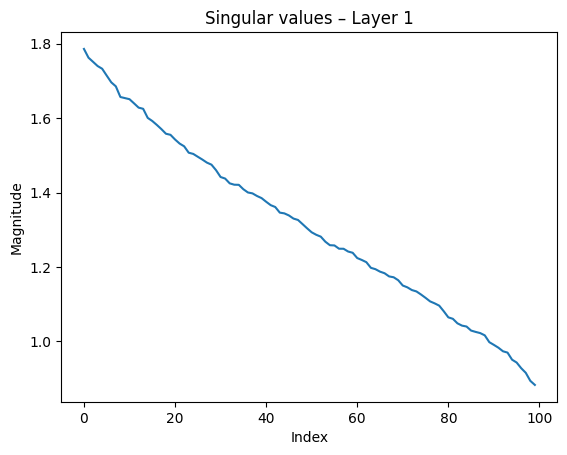

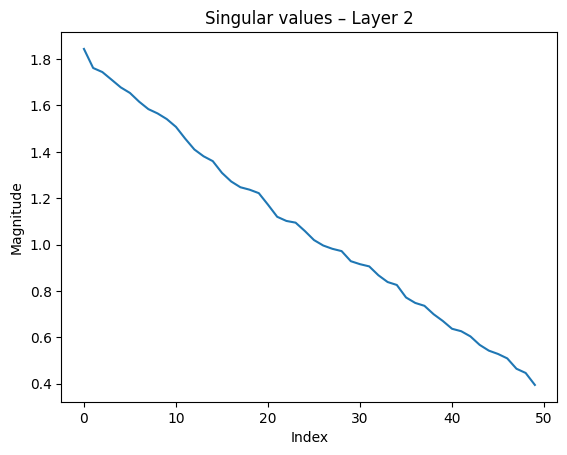

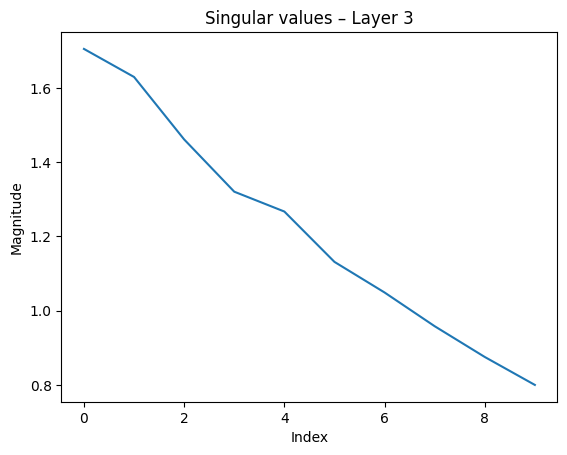

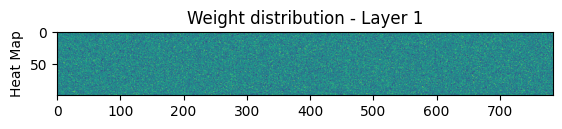

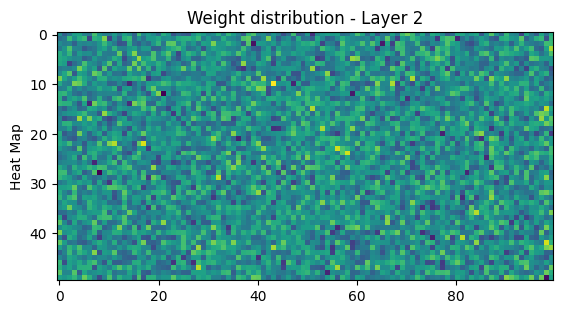

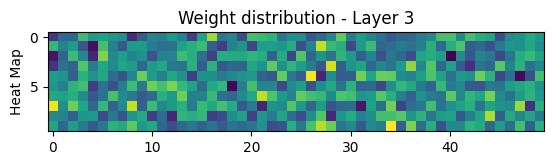

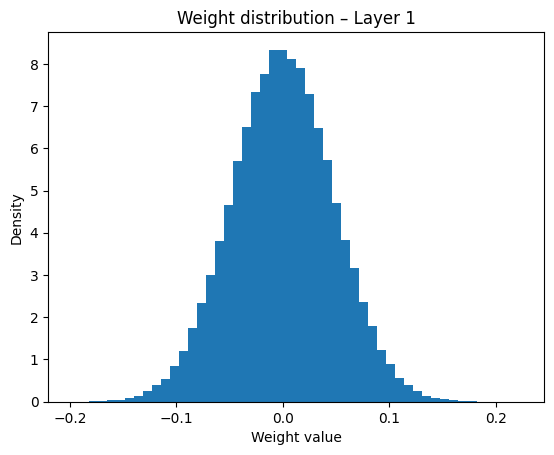

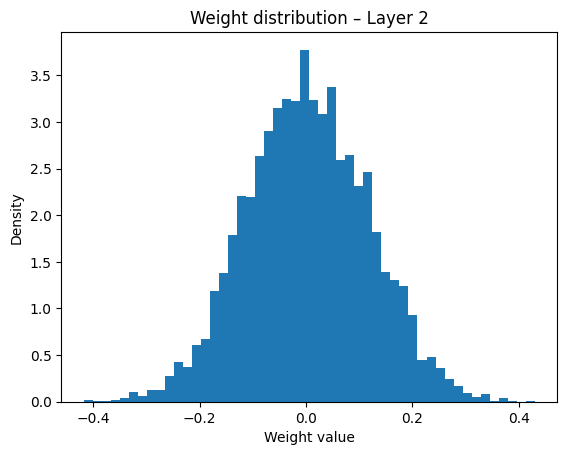

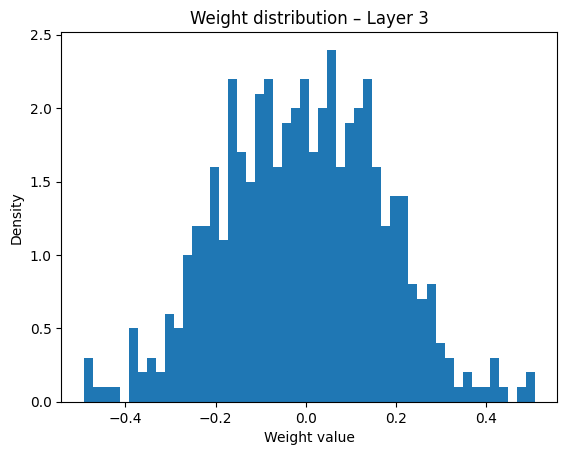

In [17]:
plot_singular_values(numpy_xavier_layers)
plot_weight_heatmap(numpy_xavier_layers)
plot_weight_distributions(numpy_xavier_layers)

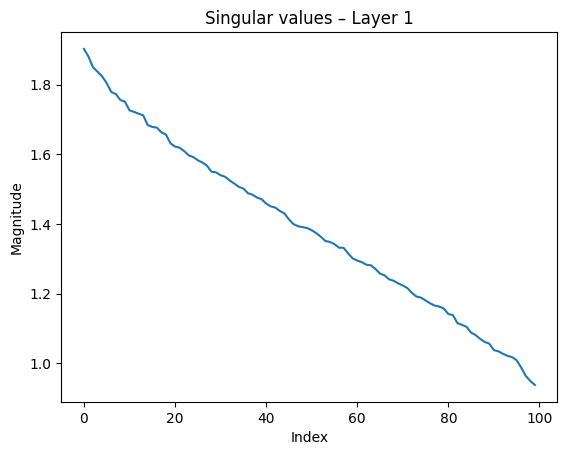

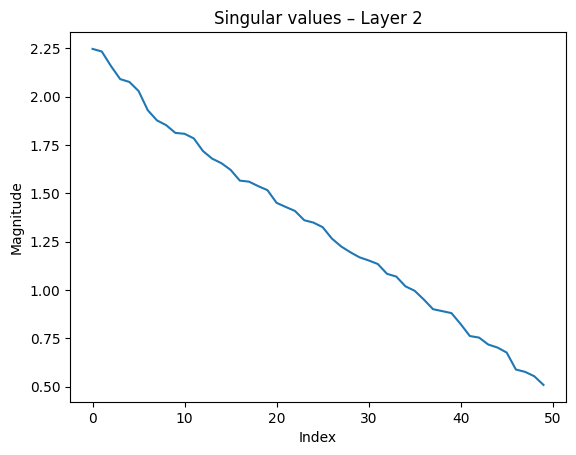

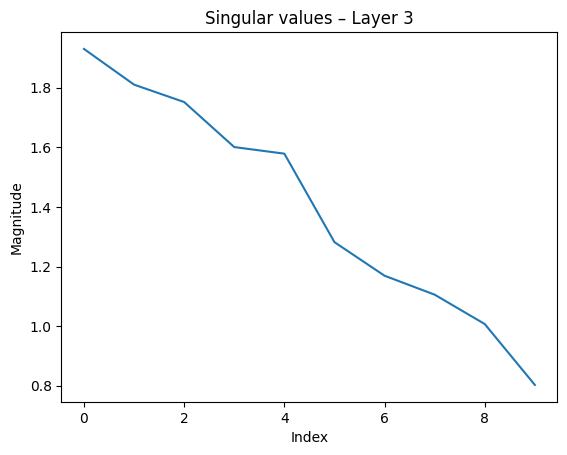

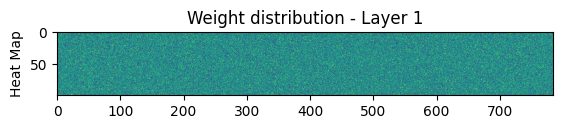

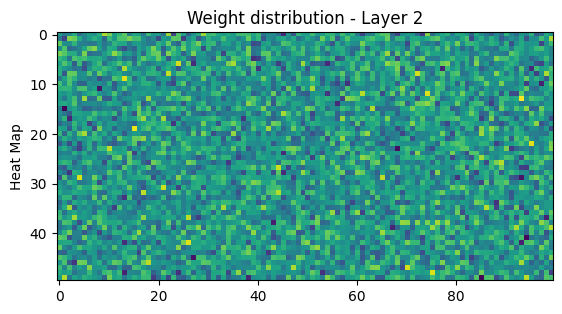

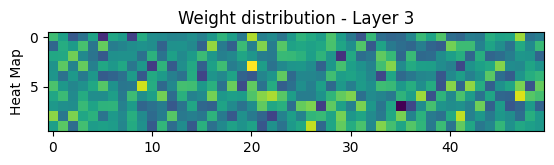

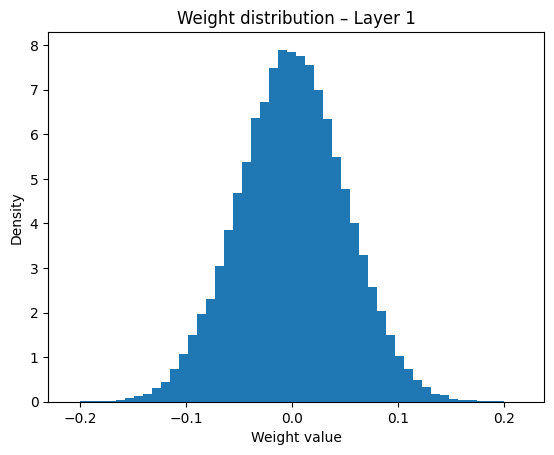

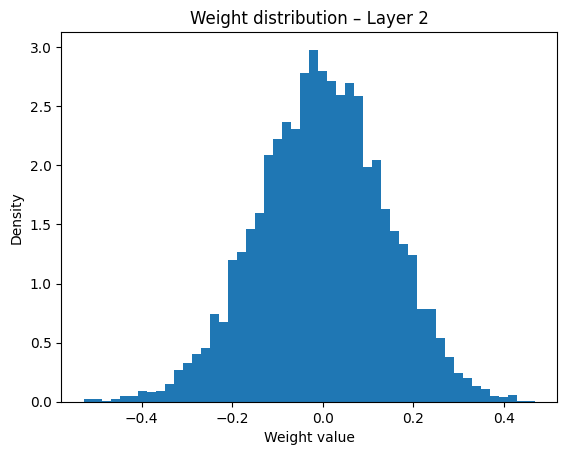

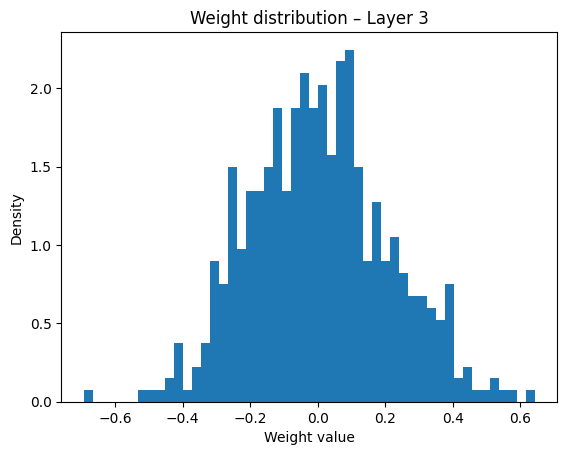

In [18]:
plot_singular_values(numpy_kaiming_layers)
plot_weight_heatmap(numpy_kaiming_layers)
plot_weight_distributions(numpy_kaiming_layers)

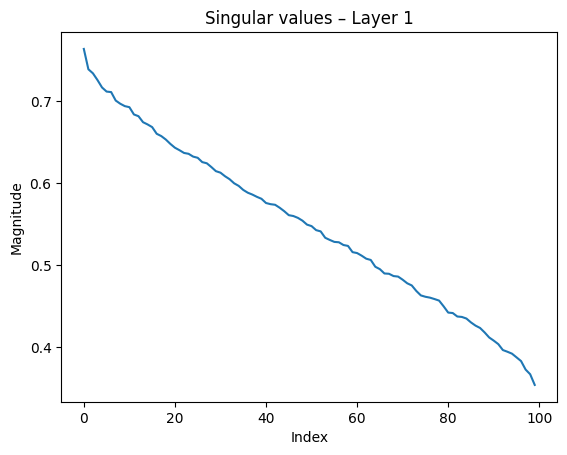

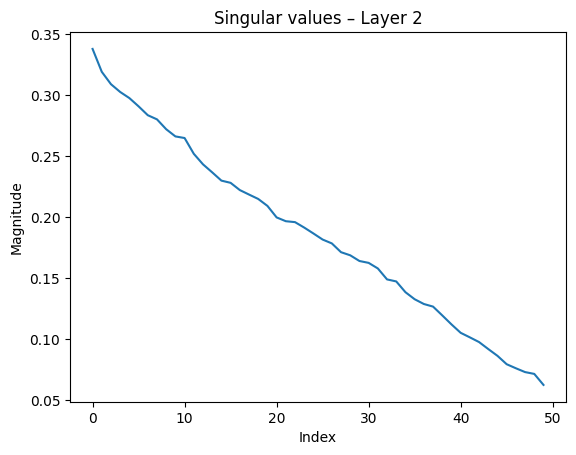

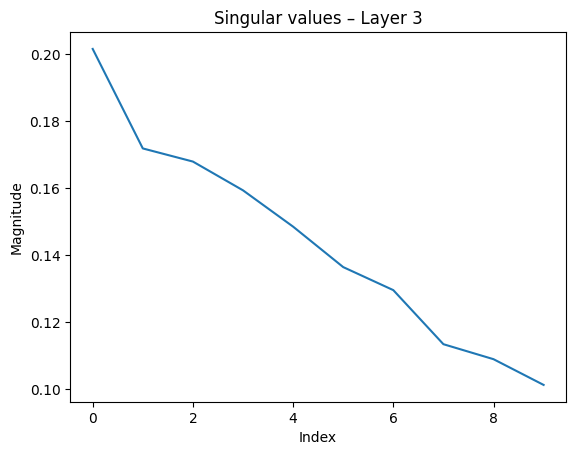

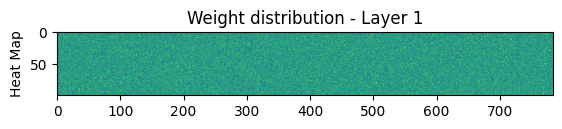

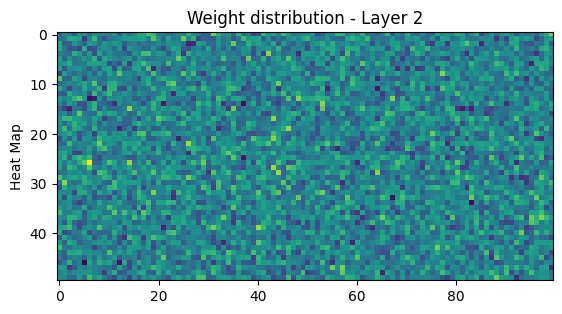

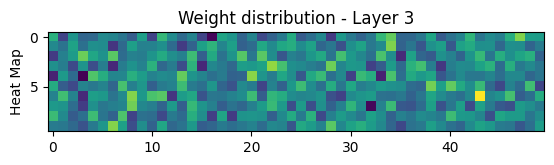

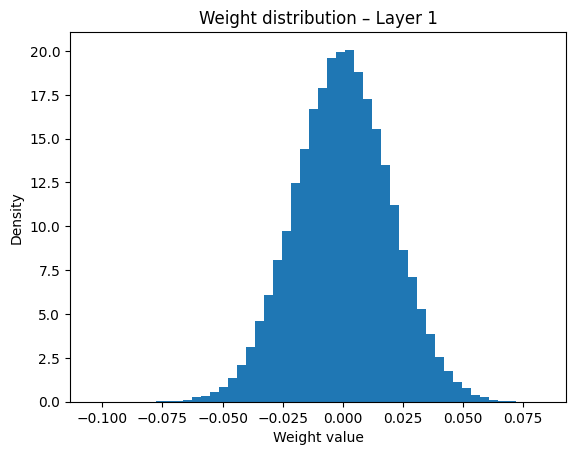

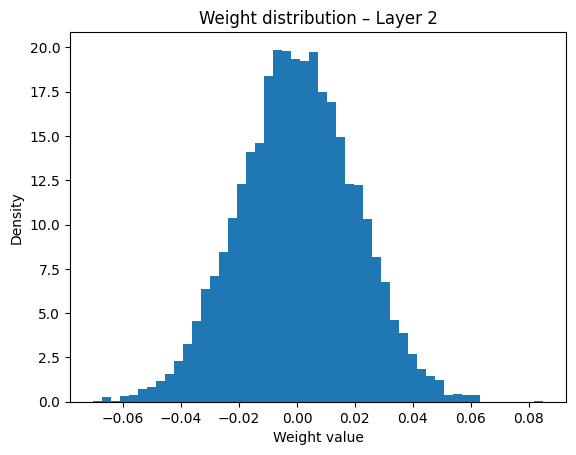

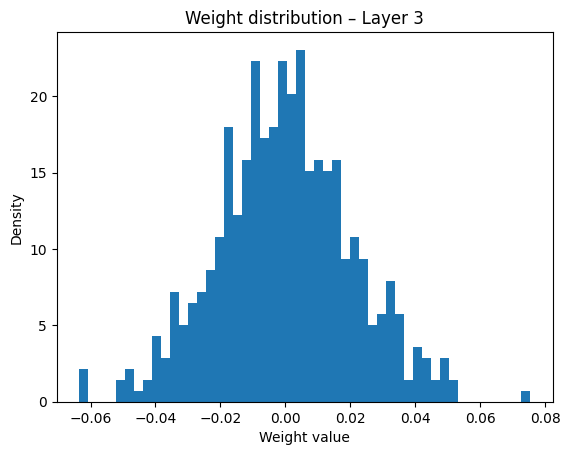

In [19]:
plot_singular_values(numpy_normal_layers)
plot_weight_heatmap(numpy_normal_layers)
plot_weight_distributions(numpy_normal_layers)

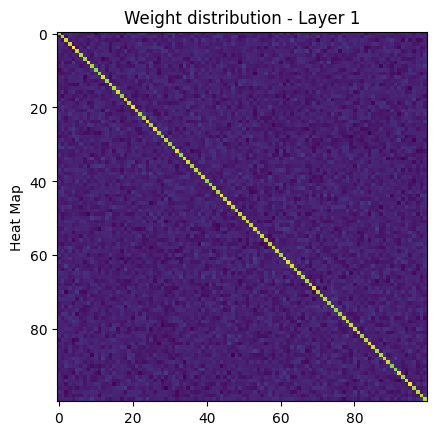

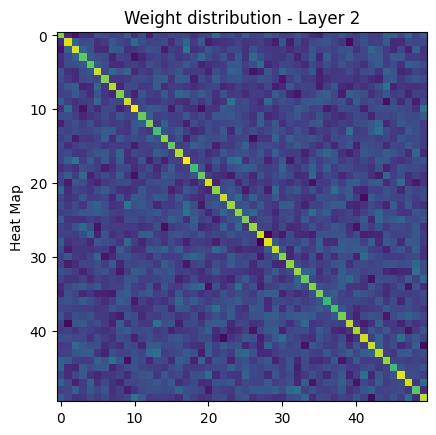

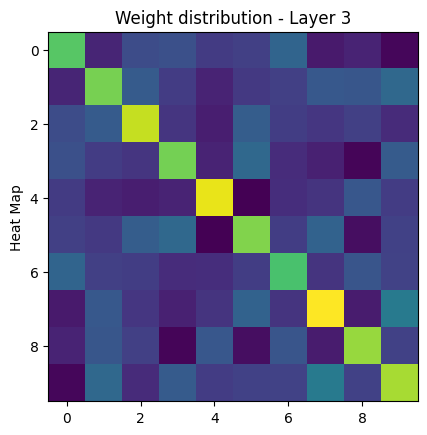

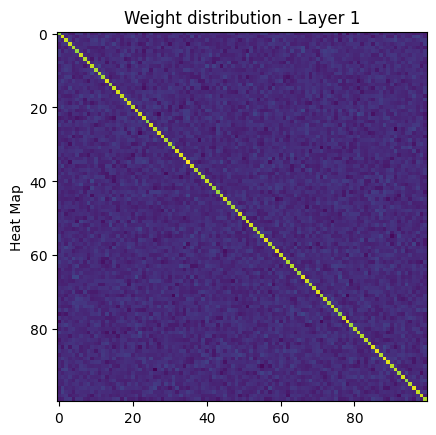

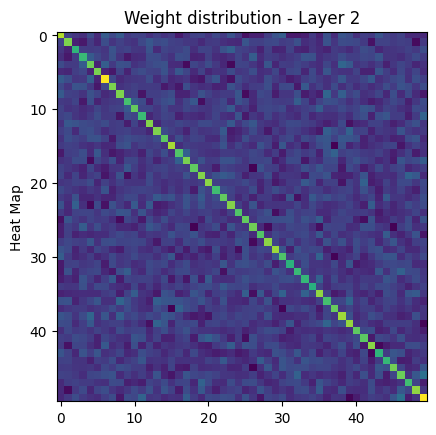

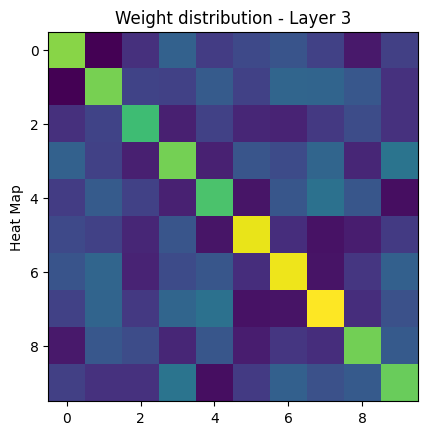

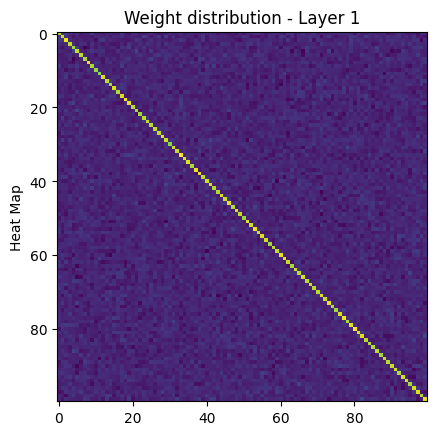

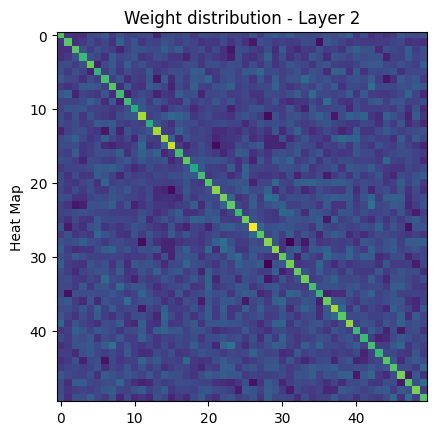

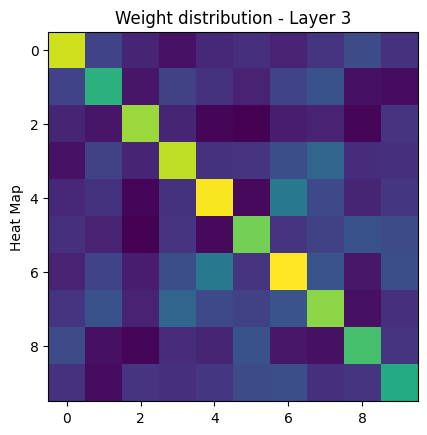

In [20]:
plot_weight_heatmap(xavier_square_matrices)
plot_weight_heatmap(kaiming_square_matrices)
plot_weight_heatmap(normal_square_matrices)